# StagePlayWriter Agent Graph - Test Notebook

This notebook provides a simple test run of the agent graph to verify:
- Graph compilation and execution
- Tool calls (create_character)
- Human-in-the-loop (human_assistance with interrupt)

In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langchain_core.runnables import RunnableConfig
from agent_graph import StagePlayWriter, input_message, StagePlayState
from IPython.display import Image, display

load_dotenv()

True

In [2]:
llm = ChatOpenAI(model="gpt-5-mini")

In [3]:
playwriter = StagePlayWriter(
    llm=llm,
    themes="Loss of innocence, Becoming Psychologically whole, Jungian Psychology, Bildung",
    vibe="Subtly, Weird and funky",
    setting="Tam Tamoree, fictional town in German Bavaria",
    number_of_chapters=2  # Keep short for testing
)

conn_checkptr = "db/graph_checkpoints/checkpoints.db"
thread_id = "test_run_1"

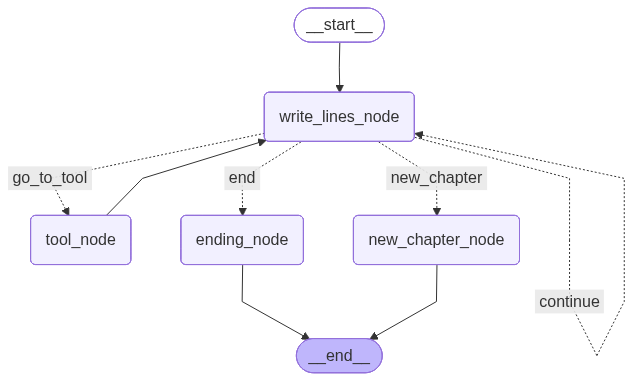

In [4]:
# Visualize the graph
async with AsyncSqliteSaver.from_conn_string(conn_checkptr) as checkpointer:
    graph = playwriter.build_graph(checkpointer)
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Could not display graph: {e}")

## Run the Agent Graph

The graph will:
1. Write lines based on the input prompt
2. Potentially call tools (create_character, human_assistance)
3. Handle human-in-the-loop interrupts when human_assistance is called

In [5]:
# Create input message to start the play
initial_input = input_message(
    "Begin the stage play. The curtain rises on a misty morning in Tam Tamoree. "
    "Introduce Luna as she walks through the town square."
)

config = RunnableConfig({"configurable": {"thread_id": thread_id}})

In [6]:
# Run the graph and stream outputs
async with AsyncSqliteSaver.from_conn_string(conn_checkptr) as checkpointer:
    graph = playwriter.build_graph(checkpointer)
    
    async for event in graph.astream(initial_input, config, stream_mode="values"):
        if "context" in event and event["context"]:
            last_msg = event["context"][-1]
            print(f"[Line {event.get('line', '?')}, Chapter {event.get('chapter', '?')}]")
            print(f"{type(last_msg).__name__}: {last_msg.content[:200]}..." if len(str(last_msg.content)) > 200 else f"{type(last_msg).__name__}: {last_msg.content}")
            
            # Check for tool calls
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"  -> Tool calls: {[tc['name'] for tc in last_msg.tool_calls]}")
            print("-" * 50)

[Line 0, Chapter 1]
HumanMessage: Begin the stage play. The curtain rises on a misty morning in Tam Tamoree. Introduce Luna as she walks through the town square.
--------------------------------------------------
[Line 1, Chapter 1]
AIMessage: Narrator: The curtain rises on Tam Tamoree: a small Bavarian town that keeps its secrets like postcards in a damp drawer. A low mist clings to the cobbles, softening angles and making every lamplight ...
--------------------------------------------------
[Line 2, Chapter 1]
AIMessage: Swedenborg: (emerging from the mist, holding a battered notebook like a talisman) You talk to empty things, Luna. Don't they ever answer back for you—or are you still collecting answers for both of us...
--------------------------------------------------
[Line 3, Chapter 1]
AIMessage: Luna: (tilting her head, an amused curl at the corner of her mouth) Answers, schmeasures. I'm not the one who converts everything into a question until it rains on purpose. Keep your t

## Check Graph State (for debugging interrupts)

In [7]:
# Check current state - useful if graph is interrupted
async with AsyncSqliteSaver.from_conn_string(conn_checkptr) as checkpointer:
    graph = playwriter.build_graph(checkpointer)
    state = await graph.aget_state(config)
    print(f"Next node: {state.next}")
    print(f"Current values: line={state.values.get('line')}, chapter={state.values.get('chapter')}")
    if state.tasks:
        print(f"Pending tasks (interrupts): {state.tasks}")

Next node: ()
Current values: line=0, chapter=2


## Resume After Human-in-the-Loop Interrupt

If the graph calls `human_assistance`, it will interrupt. Use this cell to provide a response and resume.

In [8]:
# Resume with human input after an interrupt
from langgraph.types import Command

human_response = "Luna notices a strange figure in the shadows and approaches cautiously."

async with AsyncSqliteSaver.from_conn_string(conn_checkptr) as checkpointer:
    graph = playwriter.build_graph(checkpointer)
    
    async for event in graph.astream(
        Command(resume={"data": human_response}),
        config,
        stream_mode="values"
    ):
        if "context" in event and event["context"]:
            last_msg = event["context"][-1]
            print(f"[Line {event.get('line', '?')}, Chapter {event.get('chapter', '?')}]")
            print(f"{type(last_msg).__name__}: {last_msg.content[:200]}..." if len(str(last_msg.content)) > 200 else f"{type(last_msg).__name__}: {last_msg.content}")
            print("-" * 50)

[Line 0, Chapter 2]
HumanMessage: Narrator: 
--------------------------------------------------


## View Final Story

In [9]:
# View the accumulated story
print("=" * 60)
print("FINAL STORY")
print("=" * 60)
for i, line in enumerate(playwriter.story, 1):
    print(f"{i}. {line}")
    print()

FINAL STORY
1. Begin the stage play. The curtain rises on a misty morning in Tam Tamoree. Introduce Luna as she walks through the town square.

2. Narrator: The curtain rises on Tam Tamoree: a small Bavarian town that keeps its secrets like postcards in a damp drawer. A low mist clings to the cobbles, softening angles and making every lamplight look as if it's breathing. The market stalls stand half-sleep, their awnings sagging with yesterday's rain; a clocktower in the square ticks not quite in time, its hands trembling like the twitch of a half-remembered dream. Somewhere a fountain murmurs, as if trying to practice names it won't quite remember.

Luna enters downstage center, hands jammed in the pockets of a too-big jacket, a sketchbook tucked under one arm. She walks with the impatience of someone who knows the map of her town better than its map knows itself—one boot on the cobbles, the other tapping invisible beats. She takes the mist in like an accusation and lets it out in a sm